In [1]:
!pip install ucimlrepo -q

from ucimlrepo import fetch_ucirepo

raisin = fetch_ucirepo(id=850)

X = raisin.data.features
y = raisin.data.targets.squeeze()

print("X boyutu:", X.shape)
print("y boyutu:", y.shape)
print("\nÖzellikler:")
print(X.head())
print("\nSınıf dağılımı:")
print(y.value_counts())
print("\nEksik değer sayısı:", X.isnull().sum().sum())

X boyutu: (900, 7)
y boyutu: (900,)

Özellikler:
    Area  MajorAxisLength  MinorAxisLength  Eccentricity  ConvexArea  \
0  87524       442.246011       253.291155      0.819738       90546   
1  75166       406.690687       243.032436      0.801805       78789   
2  90856       442.267048       266.328318      0.798354       93717   
3  45928       286.540559       208.760042      0.684989       47336   
4  79408       352.190770       290.827533      0.564011       81463   

     Extent  Perimeter  
0  0.758651   1184.040  
1  0.684130   1121.786  
2  0.637613   1208.575  
3  0.699599    844.162  
4  0.792772   1073.251  

Sınıf dağılımı:
Class
Kecimen    450
Besni      450
Name: count, dtype: int64

Eksik değer sayısı: 0


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

SEED = 42
np.random.seed(SEED)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("Eğitim verisi:", X_train.shape)
print("Test verisi:", X_test.shape)

Eğitim verisi: (720, 7)
Test verisi: (180, 7)


In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=SEED),
    param_grid={
        "criterion": ["gini", "entropy"],
        "max_depth": [3, 5, 7, None],
        "min_samples_leaf": [1, 2, 5]
    },
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)
dt = dt_grid.best_estimator_

print("Decision Tree en iyi parametreler:", dt_grid.best_params_)
print(f"CV doğruluğu: {dt_grid.best_score_:.4f}")

Decision Tree en iyi parametreler: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 5}
CV doğruluğu: 0.8444


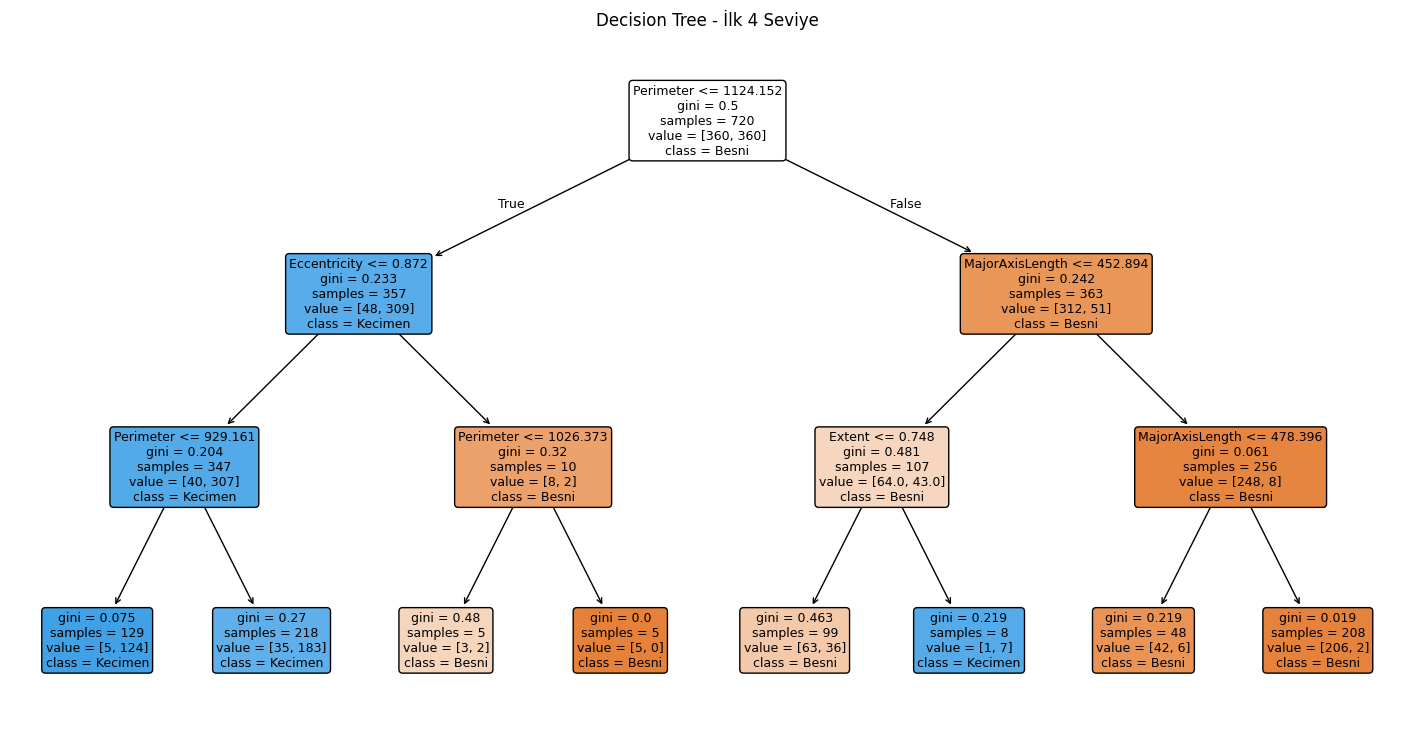

In [4]:
# decision tree
plt.figure(figsize=(18, 9))

plot_tree(
    dt,
    feature_names=list(X.columns),
    class_names=list(dt.classes_),
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)

plt.title("Decision Tree - İlk 4 Seviye")
plt.show()

In [5]:
# random forest
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=SEED),
    param_grid={
        "n_estimators": [100, 200],
        "max_depth": [5, 10, None],
        "min_samples_leaf": [1, 2]
    },
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)
rf = rf_grid.best_estimator_

print("Random Forest en iyi parametreler:", rf_grid.best_params_)
print(f"CV doğruluğu: {rf_grid.best_score_:.4f}")

Random Forest en iyi parametreler: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 200}
CV doğruluğu: 0.8625



===== Decision Tree =====
Test doğruluğu: 0.8722
              precision    recall  f1-score   support

       Besni       0.92      0.81      0.86        90
     Kecimen       0.83      0.93      0.88        90

    accuracy                           0.87       180
   macro avg       0.88      0.87      0.87       180
weighted avg       0.88      0.87      0.87       180



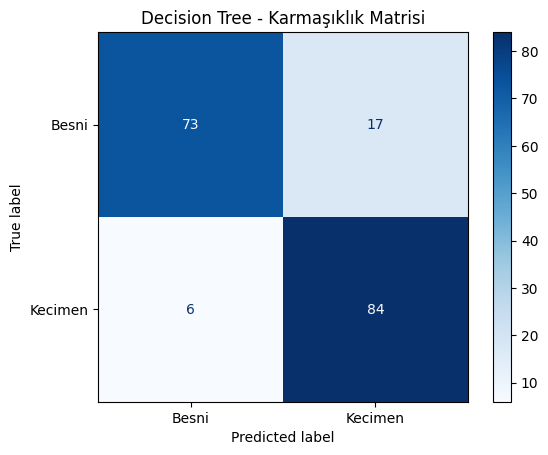


===== Random Forest =====
Test doğruluğu: 0.8722
              precision    recall  f1-score   support

       Besni       0.95      0.79      0.86        90
     Kecimen       0.82      0.96      0.88        90

    accuracy                           0.87       180
   macro avg       0.88      0.87      0.87       180
weighted avg       0.88      0.87      0.87       180



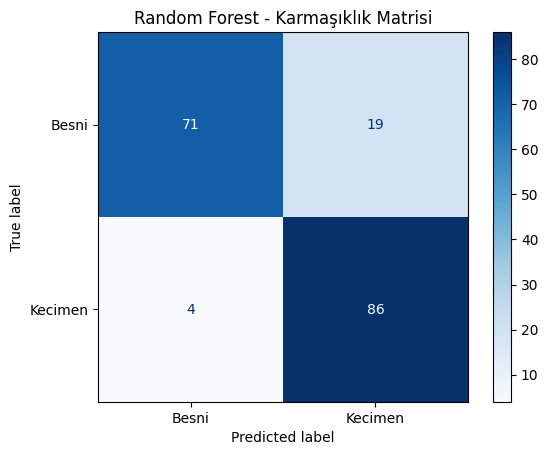

In [6]:
for name, model in [("Decision Tree", dt), ("Random Forest", rf)]:
    y_pred = model.predict(X_test)

    print(f"\n===== {name} =====")
    print(f"Test doğruluğu: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        labels=model.classes_,
        cmap="Blues"
    )
    plt.title(f"{name} - Karmaşıklık Matrisi")
    plt.show()

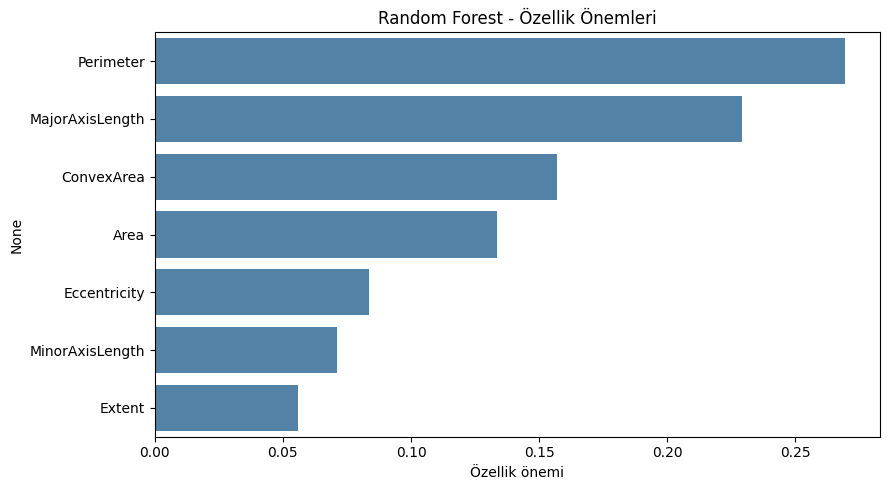

Perimeter          0.269561
MajorAxisLength    0.229340
ConvexArea         0.156957
Area               0.133450
Eccentricity       0.083552
MinorAxisLength    0.071079
Extent             0.056060
dtype: float64


In [7]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=importance.values, y=importance.index, color="steelblue")

plt.xlabel("Özellik önemi")
plt.title("Random Forest - Özellik Önemleri")
plt.tight_layout()
plt.show()

print(importance)